# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [45]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [46]:
import zipfile

ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
EXTRACT_DIR = 'heart_ds'

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

# Identify the CSV file
csv_files = glob.glob(f'{EXTRACT_DIR}/*.csv')
csv_path = csv_files[0] if csv_files else None

if csv_path:
    df = pd.read_csv(csv_path)
    # IMPORTANT: XGBoost requires labels starting at 0.
    # The dataset uses 1 and 2, so we map them to 0 and 1.
    df['heart disease'] = df['heart disease'] - 1
    display(df.head())

target = 'heart disease'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Unique values in target: {y.unique()}")

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


Train shape: (216, 13), Test shape: (54, 13)
Unique values in target: [1 0]


### Basic visual checks

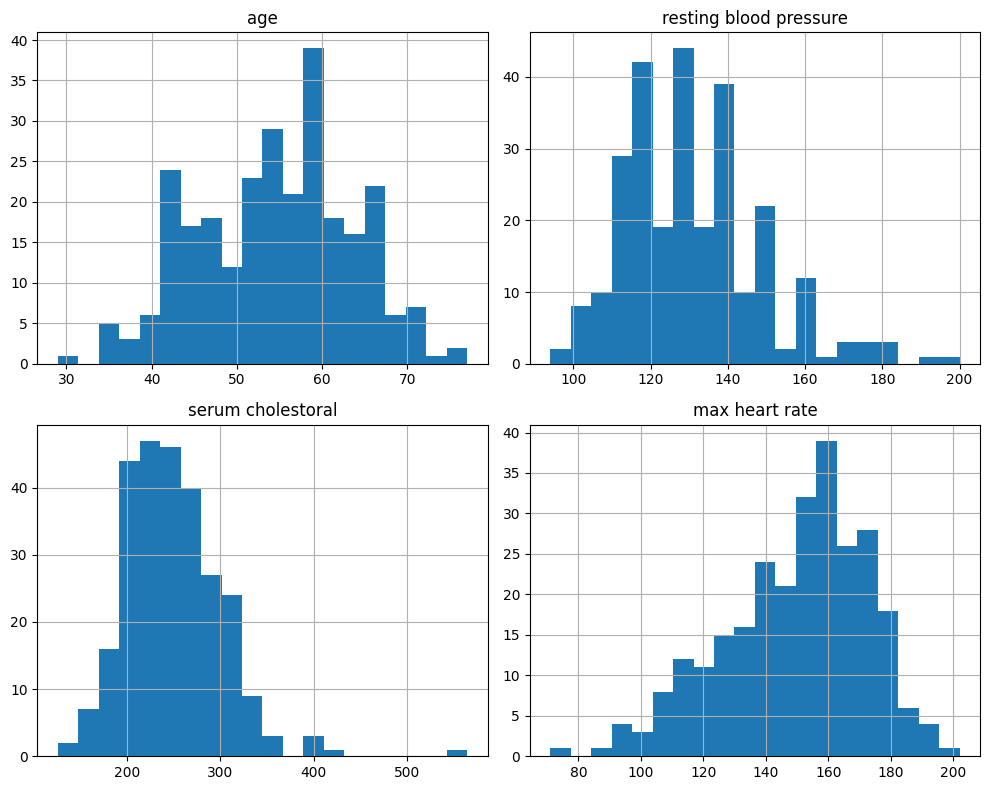

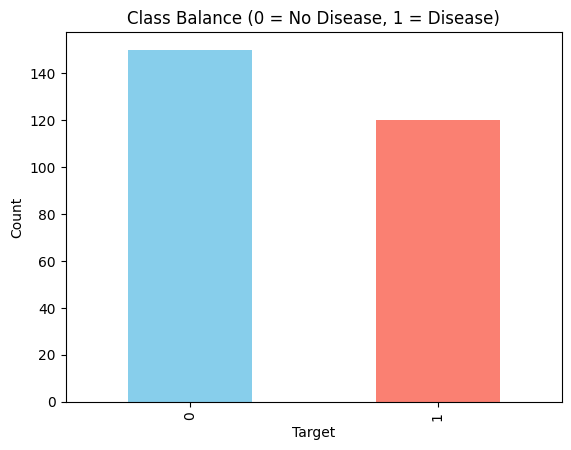

In [47]:
# Histograms for numeric columns
df[['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate']].hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()

# Class balance
df[target].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Balance (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## Preprocessing pipeline

In [48]:
# Based on the data, many columns are numerical but some are categorical encodings
num_cols = X.columns.tolist()
cat_cols = [] # For this specific dataset, we will treat all as numeric or apply scaling

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


## Helper - evaluation function

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- LR no grid ---
accuracy: 0.8519
precision: 0.7857
recall: 0.9167
f1: 0.8462


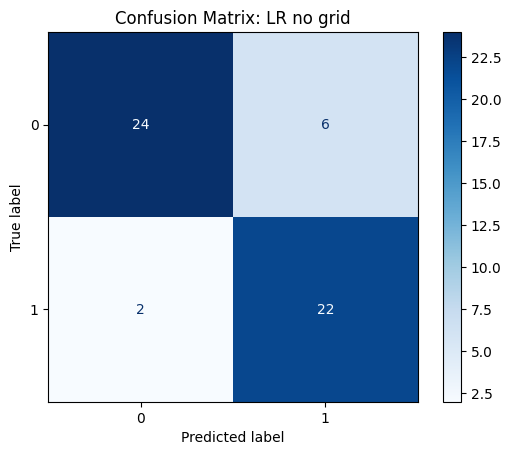

In [50]:
pipe_lr = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

pipe_lr.fit(X_train, y_train)
lr_no_gs_metrics = eval_and_report('LR no grid', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
--- LR grid ---
accuracy: 0.8519
precision: 0.7857
recall: 0.9167
f1: 0.8462


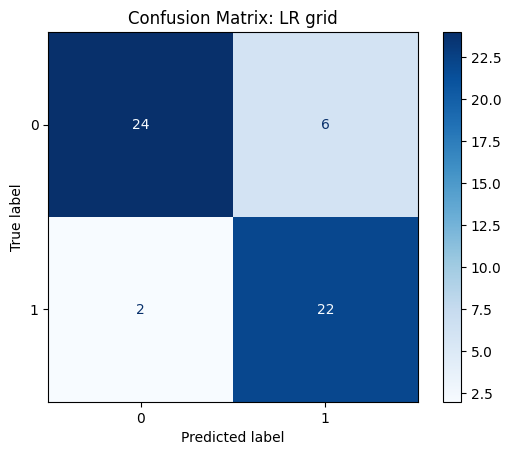

In [51]:
pipe_lr_cv = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM no grid ---
accuracy: 0.8148
precision: 0.7692
recall: 0.8333
f1: 0.8000


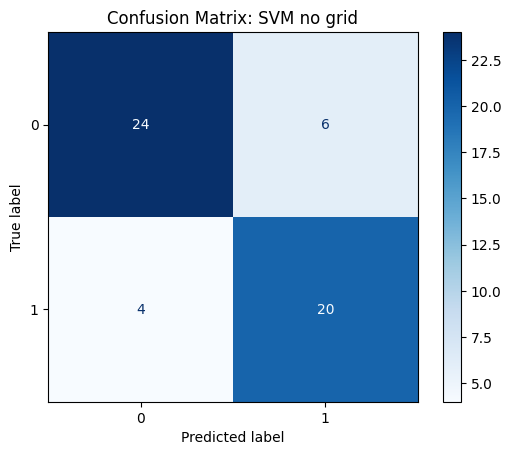

In [52]:
pipe_svm = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

--- SVM grid ---
accuracy: 0.8519
precision: 0.8077
recall: 0.8750
f1: 0.8400


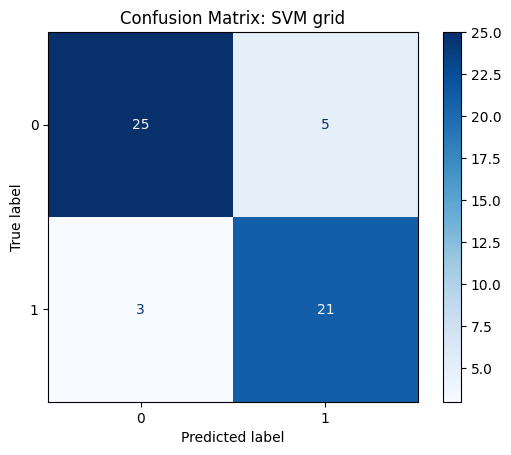

In [53]:
pipe_svm_cv = Pipeline([
    ('pre', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

--- XGB no grid ---
accuracy: 0.7963
precision: 0.7407
recall: 0.8333
f1: 0.7843


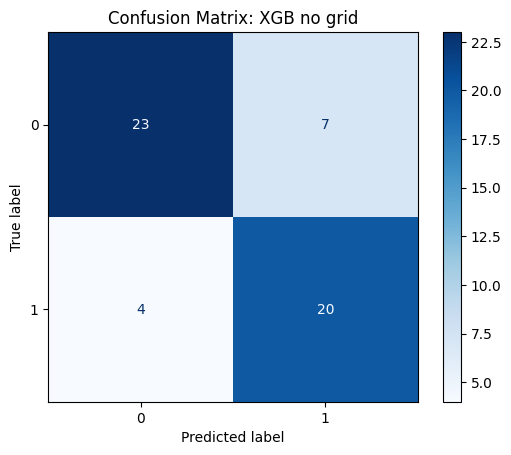

In [54]:
if XGBClassifier:
    pipe_xgb = Pipeline([
        ('pre', pre),
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE))
    ])

    pipe_xgb.fit(X_train, y_train)
    xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
else:
    print("XGBoost is not installed.")

## Exercise 7 - XGBoost with Grid Search

--- XGB grid ---
accuracy: 0.7963
precision: 0.7407
recall: 0.8333
f1: 0.7843


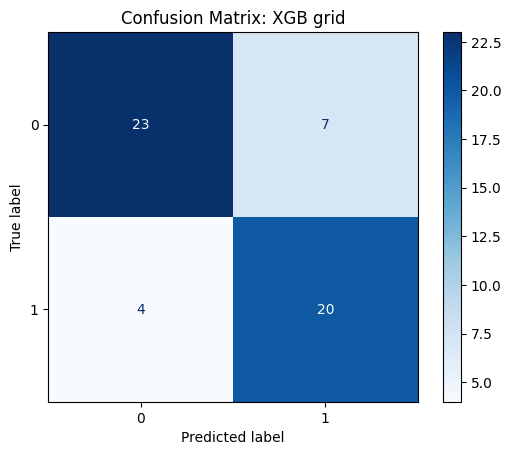

In [55]:
if XGBClassifier:
    pipe_xgb_cv = Pipeline([
        ('pre', pre),
        ('xgb', XGBClassifier(random_state=RANDOM_STATE))
    ])

    xgb_param_grid = {
        'xgb__n_estimators': [100, 300],
        'xgb__learning_rate': [0.01, 0.1],
        'xgb__max_depth': [3, 5]
    }

    grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1')
    grid_xgb.fit(X_train, y_train)

    best_xgb = grid_xgb.best_estimator_
    xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)
else:
    print("XGBoost is not installed.")

## Compare models

In [56]:
summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
if XGBClassifier:
    summary['XGB no grid'] = xgb_no_metrics
    summary['XGB grid'] = xgb_gs_metrics

df_summary = pd.DataFrame.from_dict(summary, orient='index')
display(df_summary)

,accuracy,precision,recall,f1
LR no grid,0.851852,0.785714,0.916667,0.846154
LR grid,0.851852,0.785714,0.916667,0.846154
SVM no grid,0.814815,0.769231,0.833333,0.800000
SVM grid,0.851852,0.807692,0.875000,0.840000
XGB no grid,0.796296,0.740741,0.833333,0.784314
XGB grid,0.796296,0.740741,0.833333,0.784314
